# Heaps — From Zero to LeetCode

Read this top to bottom. By the end you will know **what a heap is**, **how it works internally**, and **how to use it in Python** to solve LeetCode problems.

---
## 1. What is a Heap?

A **Heap** is a special **Binary Tree** stored inside a plain array/list.

Two rules must always hold:

| Rule | Name |
|------|------|
| Every parent ≤ its children | **Min-Heap** (root = smallest element) |
| Every parent ≥ its children | **Max-Heap** (root = largest element) |

```
Min-Heap example:

        1
       / \
      3   5
     / \ /
    7  4 6

Array: [1, 3, 5, 7, 4, 6]
```

The tree is always **complete** (filled left to right, no gaps).

---
## 2. How is a Tree stored in an Array?

Given a node at index `i` (0-based):

```
Left child  = 2*i + 1
Right child = 2*i + 2
Parent      = (i - 1) // 2
```

Example with array `[1, 3, 5, 7, 4, 6]`:

```
index:  0  1  2  3  4  5
value:  1  3  5  7  4  6

node 0 (value=1)  ->  left=1(3),  right=2(5)
node 1 (value=3)  ->  left=3(7),  right=4(4)
node 2 (value=5)  ->  left=5(6)
```

No pointers needed — the index does the work!

## 3. Two Core Operations (Heap)

A heap supports only 3 main operations:

Push (Insert)  
Pop (Remove min/max)  
Peek (Get min/max)

| Operation             | What it does                           | Steps                                                            | Example                                            | Time Complexity |
| --------------------- | -------------------------------------- | ---------------------------------------------------------------- | -------------------------------------------------- | --------------- |
| **Push (Insert)**     | Add new element                        | 1. Add at end<br>2. Bubble Up (swap with parent if needed)       | Insert `5` into `[10, 20, 30]` → `[5, 10, 30, 20]` | O(log n)        |
| **Pop (Remove root)** | Remove min (Min Heap) / max (Max Heap) | 1. Remove root<br>2. Move last element to root<br>3. Bubble Down | Pop from `[1, 3, 5, 7]` → `[3, 7, 5]`              | O(log n)        |
| **Peek**              | Get min/max without removing           | Just read `heap[0]`                                              | `[1, 3, 5]` → peek = `1`                           | O(1)            |


### 3a. Push (Insert) — O(log n)   
🧠 Idea:Always insert at the end of the array, Then fix heap using Bubble Up
📌 Example (Min Heap)

Start heap:[10, 20, 30]   
Insert 5

Step 1: Add at end [10, 20, 30, 5]
| Step | Index | Value | Parent Index | Parent Value | Action        |
| ---- | ----- | ----- | ------------ | ------------ | ------------- |
| 1    | 3     | 5     | 1            | 20           | 5 < 20 → Swap |
| 2    | 1     | 5     | 0            | 10           | 5 < 10 → Swap |
__________________________________________________________________________


### 3b. Pop (Remove Root) — O(log n)
🧠 Idea:root is always answer (min or max)  
Replace root with last element, Fix using Bubble Down    
📌 Example (Min Heap)   

Start heap:[1, 3, 5, 7]   
Step 1: Remove root (1)   
Take last element → 7      
[7, 3, 5]

| Step | Index | Value | Left Child | Right Child | Action              |
| ---- | ----- | ----- | ---------- | ----------- | ------------------- |
| 1    | 0     | 7     | 3          | 5           | 7 > 3 → Swap with 3 |

After swap:[3, 7, 5]   
Step 3: Continue check
7 has no valid children → STOP

Final Heap: [3, 7, 5]

✔ Root removed successfully
________________
### 3c. Peek — O(1)
🧠 Idea:No modification    
Just return root element
📌 Example:  
Heap:[3, 7, 5]   
Operation:
peek = heap[0]
Result:  
3



---
## 3c. Bubble Up vs Bubble Down — Side-by-Side

| | Bubble Up | Bubble Down |
|---|---|---|
| **Triggered by** | `push()` — insert | `pop()` — delete root |
| **Starts at** | Last index (bottom) | Index 0 (root / top) |
| **Moves** | Up toward root | Down toward leaves |
| **Compares with** | Its **parent** | Its **children** (picks smaller) |
| **Stops when** | Parent ≤ element, or reached root | Both children ≥ element, or no children |
| **Swaps with** | Parent | Smaller child |
_________
| Operation | Think of it as               |
| --------- | ---------------------------- |
| Push      | “Add at end → fix upwards”   |
| Pop       | “Remove top → fix downwards” |
| Peek      | “Just look at top”           |

Push → bottom to top (bubble up)  
Pop  → top to bottom (bubble down)  
Peek → just read root

### Why move the *last* element to root on pop?
Because the heap must stay a **complete tree** (filled left-to-right, no gaps).  
The only element you can safely remove without creating a gap is the last one.  
So: save root → put last at root → fix with bubble down.

### Index formulas (always needed in bubble up/down)
```
Parent of i      = (i - 1) // 2
Left child of i  = 2*i + 1
Right child of i = 2*i + 2
```

---
## 3b. Bubble Down — Step-by-Step Visual (DELETE / POP)

When you **pop**, the root (minimum) is removed.  
The **last element** is moved to the root.  
Then it "bubbles down" by comparing with its children and swapping with the smaller one.

```
Pop from heap [1, 2, 8, 5]

Step 1 — save root (answer = 1), move last element to root:
                 [5,   2,   8]
                  ↑
              5 is now at root (index 0), but may be too large

Step 2 — compare 5 with its children:
  index 0  →  left = 1 (val=2),  right = 2 (val=8)
  smallest child = index 1 (val=2)
  5 > 2  →  SWAP

                 [2,   5,   8]
                       ↑
                   5 now at index 1

Step 3 — compare 5 with its children:
  index 1  →  left = 3 (out of bounds),  right = 4 (out of bounds)
  No children → STOP

✅ Heap restored. Root = 2 (new minimum).
```

**One-liner:** Displaced element starts at the top and sinks down until both children are larger (or it hits a leaf).

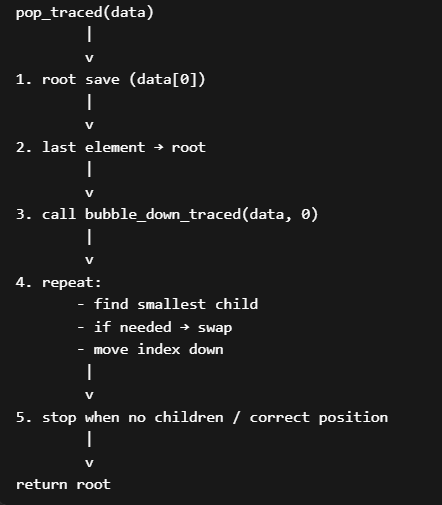

                POP OPERATION (remove root)
────────────────────────────────────────────────

STEP 1: Save root
        root = data[0]

        data = [ 1 | 2, 8, 5 ]
                 ↑
               root saved (1)

────────────────────────────────────────────────

STEP 2: Replace root with last element
        last element → root position

        [ 5, 2, 8 ]

        (heap structure temporarily broken)

────────────────────────────────────────────────

STEP 3: FIX HEAP (Bubble Down starts)

                i = 0
                 ↓
               [ 5 ]
              /     \
            [2]     [8]

        Compare children:
        left = 2
        right = 8

        smallest = 2

        5 > 2 → SWAP

────────────────────────────────────────────────

STEP 4: After swap

        [ 2, 5, 8 ]
              ↑
            new i = 1

────────────────────────────────────────────────

STEP 5: Continue Bubble Down

        Node = 5
        children = none

        → STOP

────────────────────────────────────────────────

FINAL HEAP:
        [ 2, 5, 8 ]

### 📊 Bubble Down Step-by-Step

👉 We are doing min-heap bubble down after removing root

data = [6, 3, 2, 8, 5, 1]  
i = 0    
n = 6  

| Step   | i (Index) | Node Value | Left Child (idx, val) | Right Child (idx, val) | Condition Checks         | Smallest Index | Action     | Array State        |
| ------ | --------- | ---------- | --------------------- | ---------------------- | ------------------------ | -------------- | ---------- | ------------------ |
| Start  | 0         | 6          | (1, 3)                | (2, 2)                 | init smallest = 0        | 0              | No swap    | [6, 3, 2, 8, 5, 1] |
| Step 1 | 0         | 6          | (1, 3)                | (2, 2)                 | 3 < 6 ✔ → 1, 2 < 3 ✔ → 2 | 2              | swap 6 ↔ 2 | [2, 3, 6, 8, 5, 1] |
| Step 2 | 2         | 6          | (5, 1)                | None                   | 1 < 6 ✔ → 5              | 5              | swap 6 ↔ 1 | [2, 3, 1, 8, 5, 6] |
| Step 3 | 5         | 6          | None                  | None                   | no children              | 5              | STOP       | [2, 3, 1, 8, 5, 6] |


✅ Final Output:[2, 3, 5, 7, 4, 6]

👉 “At each step, the root element keeps swapping with the smallest child until it reaches correct position.”

Start  : [6, 3, 2, 8, 5, 1]  (value 6 at root)

Swap   : index 0 (val=6) with child index 2 (val=2)
After  : [2, 3, 6, 8, 5, 1]

Swap   : index 2 (val=6) with child index 5 (val=1)
After  : [2, 3, 1, 8, 5, 6]

Stop   : 6 is already smaller than both children (or no children)
Final  : [2, 3, 1, 8, 5, 6]

In [2]:
# === Bubble Down TRACED ===
# Run this to see every swap as it happens

def bubble_down_traced(data, i):
    n = len(data) # 6  
    print(f"  Start : {data}  (value {data[i]} at root)")
    while True:
        smallest = i # index= 0 , index= 2 ,index= 5
        left, right = 2*i + 1, 2*i + 2 
        # 1, 2
        # 5,6

        if left < n and data[left] < data[smallest]: 
            #1<6 and 3<6
            # 5 < 6 and 1<2
            smallest = left
            # smallest = 1
            # smallest = 5
        if right < n and data[right] < data[smallest]: 
            #2<6 and 2<3
            #6 <6 and none < 1
            smallest = right # 2 = smallest=> value =2

        if smallest == i: 
            # 2 == 0 is False
            # 5 == 2 is False
            print(f"  Stop  : {data[i]} is already smaller than both children (or no children)")
            break

        print(f"  Swap  : index {i} (val={data[i]}) with child index {smallest} (val={data[smallest]})")
        data[i], data[smallest] = data[smallest], data[i]
        # 6, 2 = 2,6=> data = [2, 3, 6, 8, 5, 1] 
        # 1,6  = 6,1 => data = [2, 3, 1, 8, 5, 6]
        i = smallest # i = 2, i= 5
        print(f"  After : {data}")  

    print(f"  Final : {data}\n")

# pop = remove root + replace with last + restore heap order
def pop_traced(data):
    if len(data) == 1:
        return data.pop()
    root = data[0]
    data[0] = data.pop()   # move last element to root
    print(f"  Removed root={root}, moved last element to root")
    bubble_down_traced(data, 0)
    return root

# --- Demo 1: pop from [1, 2, 8, 5] ---
print("=== Pop from [1, 2, 8, 5] ===")
heap = [1, 2, 8, 5]
removed = pop_traced(heap)
print(f"  Returned: {removed}")

# --- Demo 2: pop from a bigger heap ---
print("=== Pop from [1, 3, 2, 7, 4, 5, 6] ===")
heap = [1, 3, 2, 7, 4, 5, 6]
removed = pop_traced(heap)
print(f"  Returned: {removed}")

=== Pop from [1, 2, 8, 5] ===
  Removed root=1, moved last element to root
  Start : [5, 2, 8]  (value 5 at root)
  Swap  : index 0 (val=5) with child index 1 (val=2)
  After : [2, 5, 8]
  Stop  : 5 is already smaller than both children (or no children)
  Final : [2, 5, 8]

  Returned: 1
=== Pop from [1, 3, 2, 7, 4, 5, 6] ===
  Removed root=1, moved last element to root
  Start : [6, 3, 2, 7, 4, 5]  (value 6 at root)
  Swap  : index 0 (val=6) with child index 2 (val=2)
  After : [2, 3, 6, 7, 4, 5]
  Swap  : index 2 (val=6) with child index 5 (val=5)
  After : [2, 3, 5, 7, 4, 6]
  Stop  : 6 is already smaller than both children (or no children)
  Final : [2, 3, 5, 7, 4, 6]

  Returned: 1


---
## 3a. Bubble Up — Step-by-Step Visual (INSERT)

When you **push** a value, it goes to the end of the array.  
Then it "bubbles up" by comparing with its parent and swapping if smaller.

```
Insert 1 into existing heap [2, 5, 8]

Array indices:    0    1    2    3
                 [2,   5,   8,   ?]

Step 1 — append 1 at the end:
                 [2,   5,   8,   1]
                  ↑              ↑
                root           new (index 3)

Step 2 — compare with parent:
  index 3 → parent = (3-1)//2 = 1  → value 5
  1 < 5  →  SWAP

                 [2,   1,   8,   5]
                       ↑
                   now at index 1

Step 3 — compare with parent:
  index 1 → parent = (1-1)//2 = 0  → value 2
  1 < 2  →  SWAP

                 [1,   2,   8,   5]
                  ↑
              now at index 0 (root) → STOP

✅ Heap restored. Root = 1 (the minimum).
```

**One-liner:** New element starts at the bottom and climbs up until it finds its correct spot.

data = [2, 5, 8]  
insert = 1  
data = [2, 5, 8, 1]  
i = 3

| Step   | i | Node Value | Parent Index | Parent Value | Condition           | Action | Array State  |
| ------ | - | ---------- | ------------ | ------------ | ------------------- | ------ | ------------ |
| Start  | 3 | 1          | 1            | 5            | 1 < 5 ✔             | swap   | [2, 1, 8, 5] |
| Step 1 | 1 | 1          | 0            | 2            | 1 < 2 ✔             | swap   | [1, 2, 8, 5] |
| Step 2 | 0 | 1          | -            | -            | stop (root reached) | stop   | [1, 2, 8, 5] |


In [ ]:
# === Bubble Up TRACED ===
# Run this to see every swap as it happens
# i = position of new element that is bubbling up

def bubble_up_traced(data, i):
    print(f"  Start : {data}  (new value {data[i]} at index {i})")
    while i > 0: # 3 >0, 1>0, 0>0
        parent = (i - 1) // 2 
        # parent of 3 → (3-1)//2 = 2//2 = 1
        # parent of 1 → (1-1)//2 = 0//2 = 0
        if data[i] < data[parent]:
            # data[3]<data[1]=> 1 < 5
            # data[1]< data[0]=> 1< 2
            print(f"  Swap  : index {i} (val={data[i]}) with parent index {parent} (val={data[parent]})")
            data[i], data[parent] = data[parent], data[i]
            
            # 1,5 = 5,1 => data = [2, 1, 8, 5]
            # 1,2 = 2,1 => data = [1, 2, 8, 5]
            # [2, 5, 8, 1] → [2, 1, 8, 5]
            # then → [1, 2, 8, 5]

            i = parent
            # i=1, i=0
            print(f"  After : {data}")
        else:
            print(f"  Stop  : {data[i]} >= parent {data[parent]}, no swap needed")
            break
    print(f"  Final : {data}\n")

# --- Demo 1: inserting into [2, 5, 8] ---
print("=== Insert 1 into [2, 5, 8] ===")
heap = [2, 5, 8]
heap.append(1)
bubble_up_traced(heap, len(heap) - 1)

# --- Demo 2: inserting a value that does NOT need to move ---
print("=== Insert 9 into [1, 2, 8, 5] ===")
heap = [1, 2, 8, 5]
heap.append(9)
bubble_up_traced(heap, len(heap) - 1)

---
## 4. Build a Min-Heap from scratch (to understand internals)

push(5), push(3), push(8), push(1), pop()

| Step | Operation | Action                                                 | Heap (`self.data`) |
| ---- | --------- | ------------------------------------------------------ | ------------------ |
| 1    | push(5)   | append → [5] (no bubble)                               | [5]                |
| 2    | push(3)   | append → [5,3] → swap with parent                      | [3,5]              |
| 3    | push(8)   | append → [3,5,8] (no swap)                             | [3,5,8]            |
| 4    | push(1)   | append → [3,5,8,1] → swap with 5 → swap with 3         | [1,3,8,5]          |
| 5    | pop()     | remove root (1), move last (5) → [5,3,8] → swap with 3 | [3,5,8]            |


📊 Dry Run (_bubble_up)   
👉 Example: inserting 1 into heap [3, 5, 8]

| Step | i | Parent Index | Compare       | Action    | Heap State   |
| ---- | - | ------------ | ------------- | --------- | ------------ |
| 1    | 3 | 1            | 1 < 5         | swap(1,5) | [3, 1, 8, 5] |
| 2    | 1 | 0            | 1 < 3         | swap(1,3) | [1, 3, 8, 5] |
| 3    | 0 | —            | stop (i == 0) | done      | [1, 3, 8, 5] |

i = 3   
Reason: new element list ke last index par insert hota hai.


[5, 3, 8]

Ab _bubble_down(0) chalega (i = 0)

| Step | i | left (2i+1) | right (2i+2) | Compare      | Smallest | Action    | Heap State |
| ---- | - | ----------- | ------------ | ------------ | -------- | --------- | ---------- |
| 1    | 0 | 1 → 3       | 2 → 8        | 3 < 5 ✔      | 1        | swap(5,3) | [3, 5, 8]  |
| 2    | 1 | 3           | 4            | out of range | 1        | stop      | [3, 5, 8]  |


In [14]:
class MinHeap:
    def __init__(self):
        self.data = []

    def push(self, val):
        self.data.append(val)
        self._bubble_up(len(self.data) - 1)

    def pop(self):
        if len(self.data) == 1:
            return self.data.pop()
        root = self.data[0]
        self.data[0] = self.data.pop()   # move last to root
        self._bubble_down(0)
        return root

    def peek(self):
        return self.data[0]

    def _bubble_up(self, i):
        while i > 0:  # i = 3 → 3 > 0 ✔
            parent = (i - 1) // 2
            # i = 3 → parent = (3-1)//2 = 1
            # next i = 1 → parent = (1-1)//2 = 0

            if self.data[i] < self.data[parent]:   # check violation
                # Step 1: data[3]=1 < data[1]=5 ✔
                # Step 2: data[1]=1 < data[0]=3 ✔

                self.data[i], self.data[parent] = self.data[parent], self.data[i]

                # After Step 1 swap (i=3, parent=1):
                # [3, 1, 8, 5]

                # After Step 2 swap (i=1, parent=0):
                # [1, 3, 8, 5]

                i = parent  # move up
                # Step 1: i = 1
                # Step 2: i = 0

            else:
                break  # stop if heap property satisfied

    def _bubble_down(self, i):
        n = len(self.data)  # data = [5, 3, 8], n = 3

        while True:
            smallest = i  # start with current index → i = 0

            left, right = 2*i + 1, 2*i + 2
            # left = 1, right = 2

            if left < n and self.data[left] < self.data[smallest]:
                # 1 < 3 ✔ and 3 < 5 ✔
                smallest = left
                # smallest = 1 (value = 3)

            if right < n and self.data[right] < self.data[smallest]:
                # 2 < 3 ✔ but 8 < 3 ❌ (false)
                # so NO change, smallest stays 1
                pass

            if smallest == i:
                # if no smaller child found → stop
                break

            # swap parent with smallest child
            self.data[i], self.data[smallest] = self.data[smallest], self.data[i]
            # swap index 0 and 1 → [3, 5, 8]

            i = smallest
            # i = 1 (move down to new position)

            # next iteration:
            # left = 3, right = 4 → out of range
            # loop breaks

    def __len__(self):
        return len(self.data)

    def __repr__(self):
        return str(self.data)

In [15]:
h = MinHeap()
for v in [5, 3, 8, 1, 4, 2]:
    h.push(v)
    print(f"pushed {v} -> heap: {h}")

print()
while len(h):
    print(f"popped {h.pop()} -> heap: {h}")

pushed 5 -> heap: [5]
pushed 3 -> heap: [3, 5]
pushed 8 -> heap: [3, 5, 8]
pushed 1 -> heap: [1, 3, 8, 5]
pushed 4 -> heap: [1, 3, 8, 5, 4]
pushed 2 -> heap: [1, 3, 2, 5, 4, 8]

popped 1 -> heap: [3, 5, 2, 8, 4]
popped 3 -> heap: [4, 5, 2, 8]
popped 4 -> heap: [5, 8, 2]
popped 5 -> heap: [2, 8]
popped 2 -> heap: [8]
popped 8 -> heap: []


---
## 5. Python's Built-in: `heapq` (always Min-Heap)

You will **never** write the class above in interviews. Use `heapq`.

```python
import heapq

heapq.heappush(heap, val)    # push
heapq.heappop(heap)          # pop smallest
heap[0]                      # peek smallest  (O(1))
heapq.heapify(list)          # convert list to heap IN-PLACE  O(n)
heapq.nsmallest(k, iterable) # k smallest elements
heapq.nlargest(k, iterable)  # k largest elements
```

| Step | Operation | Heap State         |
| ---- | --------- | ------------------ |
| 1    | push 5    | [5]                |
| 2    | push 3    | [3, 5]             |
| 3    | push 8    | [3, 5, 8]          |
| 4    | push 1    | [1, 3, 8, 5]       |
| 5    | push 4    | [1, 3, 8, 5, 4]    |
| 6    | push 2    | [1, 3, 2, 5, 4, 8] |


| Step | Operation | Output | Heap After Pop  |
| ---- | --------- | ------ | --------------- |
| 1    | pop       | 1      | [2, 3, 8, 5, 4] |
| 2    | pop       | 2      | [3, 4, 8, 5]    |
| 3    | pop       | 3      | [4, 5, 8]       |
| 4    | pop       | 4      | [5, 8]          |
| 5    | pop       | 5      | [8]             |
| 6    | pop       | 8      | []              |


In [3]:
import heapq

heap = []
for v in [5, 3, 8, 1, 4, 2]:
    heapq.heappush(heap, v)

print("heap array:", heap)          # NOT sorted, but heap[0] is always min
print("min (peek):", heap[0])

print("\npopping in order:")
while heap:
    print(heapq.heappop(heap), end=" ")

heap array: [1, 3, 2, 5, 4, 8]
min (peek): 1

popping in order:
1 2 3 4 5 8 

---
## 6. Trick: Max-Heap in Python

`heapq` only gives a min-heap. To get a **max-heap**, store values as **negatives**.

| Step | Value (v) | Pushed (-v) | Heap State               |
| ---- | --------- | ----------- | ------------------------ |
| 1    | 5         | -5          | [-5]                     |
| 2    | 3         | -3          | [-5, -3]                 |
| 3    | 8         | -8          | [-8, -3, -5]             |
| 4    | 1         | -1          | [-8, -3, -5, -1]         |
| 5    | 4         | -4          | [-8, -4, -5, -1, -3]     |
| 6    | 2         | -2          | [-8, -4, -5, -1, -3, -2] |

After all insertions 
Internal heap → [-8, -4, -5, -1, -3, -2]   
max (peek) → 8 (because -(-8))  
popping elements
| Step | Popped (raw) | Output (-value) | Heap After Pop       |
| ---- | ------------ | --------------- | -------------------- |
| 1    | -8           | 8               | [-5, -4, -2, -1, -3] |
| 2    | -5           | 5               | [-4, -3, -2, -1]     |
| 3    | -4           | 4               | [-3, -1, -2]         |
| 4    | -3           | 3               | [-2, -1]             |
| 5    | -2           | 2               | [-1]                 |
| 6    | -1           | 1               | []                   |



max-heap using heapq is created by inserting negative values, since Python only supports a min-heap.
The largest element becomes the smallest negative value, allowing us to retrieve it first and convert it back by negating again.

In [4]:
import heapq

nums = [5, 3, 8, 1, 4, 2]
max_heap = []

for v in nums:
    heapq.heappush(max_heap, -v)   # store negative

print("max (peek):", -max_heap[0])  # negate back

print("\npopping in descending order:")
while max_heap:
    print(-heapq.heappop(max_heap), end=" ")

max (peek): 8

popping in descending order:
8 5 4 3 2 1 

---
## 7. Heap with Custom Objects (tuples)

Push tuples `(priority, data)` — Python compares tuples element by element.

Key idea  
heapq in Python implements a min-heap  
Smallest priority number comes out first  

| Step | Operation        | Heap State                           | Output             |
| ---- | ---------------- | ------------------------------------ | ------------------ |
| 1    | push (3, low)    | [(3, low)]                           | —                  |
| 2    | push (1, urgent) | [(1, urgent), (3, low)]              | —                  |
| 3    | push (2, medium) | [(1, urgent), (3, low), (2, medium)] | —                  |
| 4    | pop              | [(2, medium), (3, low)]              | priority=1: urgent |
| 5    | pop              | [(3, low)]                           | priority=2: medium |
| 6    | pop              | []                                   | priority=3: low    |


In [5]:
import heapq

tasks = []
heapq.heappush(tasks, (3, "low priority task"))
heapq.heappush(tasks, (1, "urgent task"))
heapq.heappush(tasks, (2, "medium task"))

while tasks:
    priority, name = heapq.heappop(tasks)
    print(f"priority={priority}: {name}")

priority=1: urgent task
priority=2: medium task
priority=3: low priority task


---
## 8. heapify — O(n) bulk conversion

If you already have a list and want to turn it into a heap, use `heapify`. It's O(n) — faster than pushing one by one (which is O(n log n)).

| Step | Operation             | List State (`nums`) | Note                      |
| ---- | --------------------- | ------------------- | ------------------------- |
| 1    | Initial list          | [5, 3, 8, 1, 4, 2]  | Unsorted                  |
| 2    | `heapq.heapify(nums)` | [1, 3, 2, 5, 4, 8]  | Converted to **min-heap** |
| 3    | Access `nums[0]`      | 1                   | Smallest element          |


In [6]:
import heapq

nums = [5, 3, 8, 1, 4, 2]
heapq.heapify(nums)          # modifies list in-place
print("after heapify:", nums)
print("min:", nums[0])

after heapify: [1, 3, 2, 5, 4, 8]
min: 1


---
## 9. Time & Space Complexity Cheatsheet

| Operation | Time |
|-----------|------|
| push | O(log n) |
| pop | O(log n) |
| peek (heap[0]) | O(1) |
| heapify | O(n) |
| nsmallest / nlargest | O(n log k) |

Space: O(n)

---
## 10. When to Use a Heap on LeetCode

Spot these keywords in a problem — reach for a heap:

| Keyword / Pattern | Heap Type |
|---|---|
| "kth largest" | Min-Heap of size k |
| "kth smallest" | Max-Heap of size k |
| "top k frequent" | Min-Heap of size k |
| "merge k sorted lists" | Min-Heap |
| "running median" | Min-Heap + Max-Heap |
| "task scheduler" | Max-Heap |
| "find minimum at every step" | Min-Heap |
| Dijkstra's shortest path | Min-Heap |

---
## 11. Mini Practice — Kth Largest Element (LeetCode 215)

**Problem:** Given an integer array `nums` and integer `k`, return the kth largest element.

**Idea:** Keep a min-heap of size k. The root (smallest in heap) is the kth largest.

nums = [3,2,1,5,6,4], k = 2

| Step | num | Heap after push | Action (if size > k) | Final Heap |
| ---- | --- | --------------- | -------------------- | ---------- |
| 1    | 3   | [3]             | —                    | [3]        |
| 2    | 2   | [2,3]           | —                    | [2,3]      |
| 3    | 1   | [1,3,2]         | pop 1                | [2,3]      |
| 4    | 5   | [2,3,5]         | pop 2                | [3,5]      |
| 5    | 6   | [3,5,6]         | pop 3                | [5,6]      |
| 6    | 4   | [4,6,5]         | pop 4                | [5,6]      |

kth largest = 5


In [7]:
import heapq

def findKthLargest(nums, k):
    heap = []  # min-heap of size k
    for num in nums:
        heapq.heappush(heap, num)
        if len(heap) > k:
            heapq.heappop(heap)   # remove smallest, keep k largest
    return heap[0]               # smallest among k largest = kth largest

print(findKthLargest([3,2,1,5,6,4], 2))   # 5
print(findKthLargest([3,2,3,1,2,4,5,5,6], 4))  # 4

5
4


---
## 12. Mini Practice — Top K Frequent Elements (LeetCode 347)

Input 1:- nums = [1,1,1,2,2,3], k = 2    
Frequency map:-{1:3, 2:2, 3:1}

| Step | (num, freq) | Heap after push       | Action (if size > k) | Final Heap     |
| ---- | ----------- | --------------------- | -------------------- | -------------- |
| 1    | (1,3)       | [(3,1)]               | —                    | [(3,1)]        |
| 2    | (2,2)       | [(2,2), (3,1)]        | —                    | [(2,2), (3,1)] |
| 3    | (3,1)       | [(1,3), (3,1), (2,2)] | pop (1,3)            | [(2,2), (3,1)] |

✅ Result :- [2, 1]
(Note: order may vary → [1,2] or [2,1])

In [ ]:
import heapq
from collections import Counter

def topKFrequent(nums, k):
    count = Counter(nums)             # {num: frequency}
    # min-heap: keep k most frequent
    # store (freq, num) so heap compares by frequency
    heap = []
    for num, freq in count.items():
        heapq.heappush(heap, (freq, num))
        if len(heap) > k:
            heapq.heappop(heap)       # remove least frequent
    return [num for freq, num in heap]

print(topKFrequent([1,1,1,2,2,3], 2))   # [1, 2]
print(topKFrequent([1], 1))             # [1]

---
## Summary

```
Heap = Complete Binary Tree stored in array
  Min-Heap  ->  root is always minimum
  Max-Heap  ->  root is always maximum

Python heapq = Min-Heap only
  Max-Heap trick: push -value, pop and negate back

Key operations:
  heapq.heappush(h, val)   O(log n)
  heapq.heappop(h)         O(log n)
  h[0]                     O(1)  peek
  heapq.heapify(list)      O(n)

LeetCode pattern: "kth", "top k", "merge k" -> heap
```

Now open `1-leetcode-heaps.ipynb` and the problems will make sense!